# Mortgage Prepayment Simulation — Monte Carlo and Stochastic Rate Modelling
### Stochastic Interest Rate Models

This is the first notebook of the project **"Mortgage Prepayment Simulation — Monte Carlo and Stochastic Rate Modelling"**

This notebook defines functions to simulate interest rate paths for modelling prepayment rates on a pool of loan. The notebook defines functions for two stochastic interest rate models - Vasicek Model and Cox-Ingersoll-Ross Model (CIR). 

The notebook plots simulated interest rate paths for both the models to compare the interest rates simulated. A final selection between the two models is being made in this notebook which is then exported to the final simulation engine to model prepayment rates. 

In [ ]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

In [ ]:
#Define a function to simulate vasicek interest rate paths
def simulate_vasicek_paths(initial_rate, a, b, sigma, T, steps, number_of_paths):
    dt = T/steps
    path_matrix = np.zeros((number_of_paths,steps))
    for i in range(number_of_paths):
        path_matrix[i][0]=initial_rate
        for j in range(1,steps):
            path_matrix[i][j]=path_matrix[i][j-1]+a*(b-path_matrix[i][j-1])*dt+sigma*np.sqrt(dt)*np.random.normal()
    return path_matrix

In [ ]:
#Define a function to simulate CIR interest rate paths
def simulate_CIR_paths(initial_rate, a, b, sigma, T, steps, number_of_paths):
    dt = T/steps
    path_matrix = np.zeros((number_of_paths,steps))
    for i in range(number_of_paths):
        path_matrix[i][0]=initial_rate
        for j in range(1,steps):
            path_matrix[i][j]=path_matrix[i][j-1]+a*(b-path_matrix[i][j-1])*dt+sigma*np.sqrt(dt)*np.random.normal()*np.sqrt(path_matrix[i][j-1])
    return path_matrix

In [ ]:
#Simulating a sample vasicek interest rate path
if __name__ == "__main__":
    simulated_paths_vasicek = simulate_vasicek_paths(initial_rate=0.04,a=0.15,b=0.03,sigma=0.02,T=30,steps=360,number_of_paths=1000)

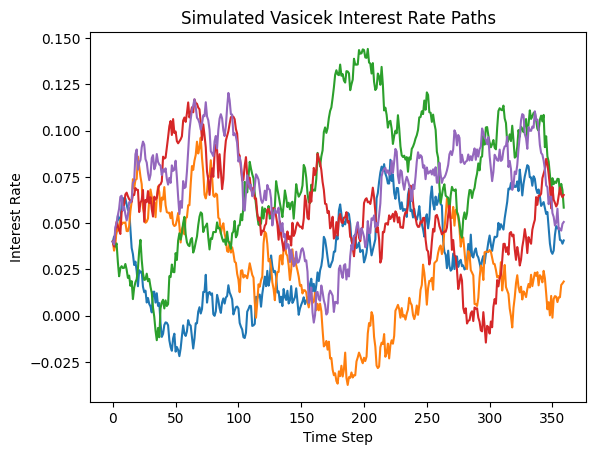

In [ ]:
#Plotting the interest rate paths
if __name__ == "__main__":
    for i in range(5):
        plt.plot(simulated_paths_vasicek[i])
    plt.title("Simulated Vasicek Interest Rate Paths")
    plt.xlabel("Time Step")
    plt.ylabel("Interest Rate")
    plt.show()

In [ ]:
#Simulating a sample CIR interest rate path
if __name__ == "__main__":
    simulated_paths_CIR = simulate_CIR_paths(initial_rate=0.04,a=0.15,b=0.03,sigma=0.02,T=30,steps=360,number_of_paths=1000)

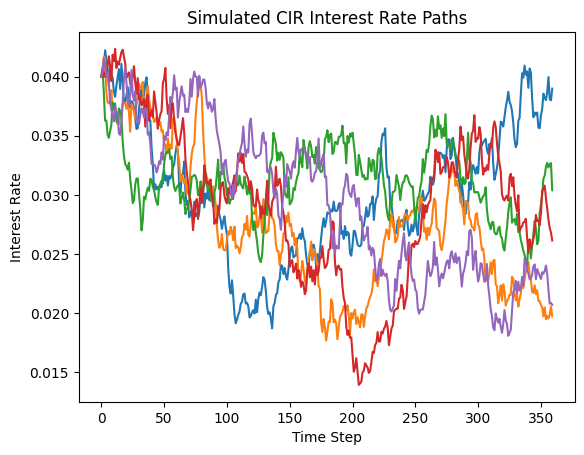

In [ ]:
#Plotting the interest rate paths
if __name__ == "__main__":
    for i in range(5):
        plt.plot(simulated_paths_CIR[i])
    plt.title("Simulated CIR Interest Rate Paths")
    plt.xlabel("Time Step")
    plt.ylabel("Interest Rate")
    plt.show()

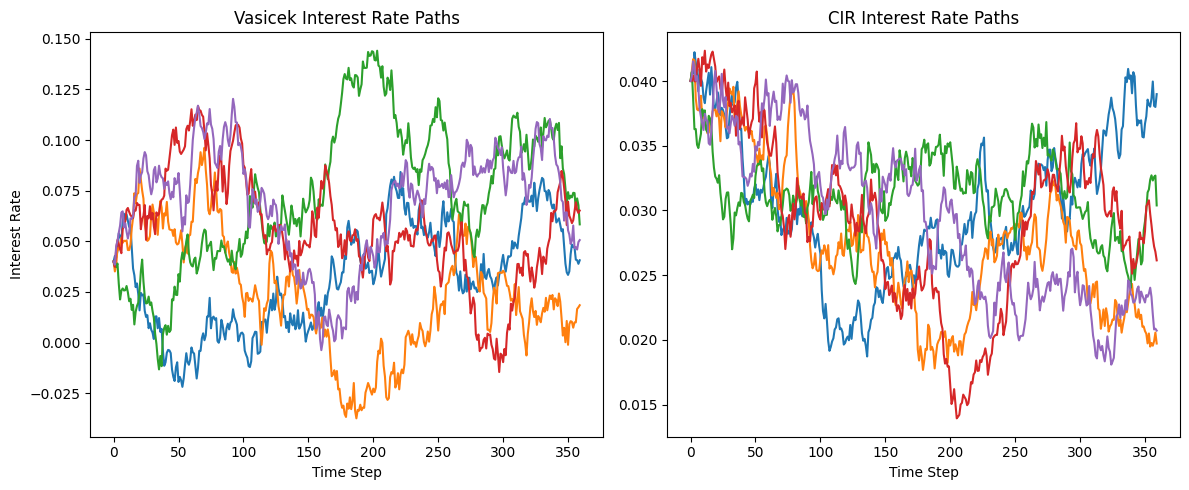

In [ ]:
#Comparing CIR and Vasicek paths in one plot
if __name__ == "__main__":
    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    # Vasicek
    for i in range(5):
        ax[0].plot(simulated_paths_vasicek[i])
    ax[0].set_title("Vasicek Interest Rate Paths")
    ax[0].set_xlabel("Time Step")
    ax[0].set_ylabel("Interest Rate")

    # CIR
    for i in range(5):
        ax[1].plot(simulated_paths_CIR[i])
    ax[1].set_title("CIR Interest Rate Paths")
    ax[1].set_xlabel("Time Step")

    plt.tight_layout()
    plt.show()

Mean reversion can be seen in both Vasicek and CIR interest rate paths as expected. 

Interest rates can be negative if simulated using Vasicek model, but are strictly positive if simulated using CIR paths. For our prepayment rate analysis, we can select CIR since we assume positive interest rates only. Negative interest rates may produce economically meaningless prepayment rates. 

In [ ]:
#Function to choose the interest rate model and simulate interest rate paths.
def simulate_paths_based_on_chosen_model(model,initial_rate=0.04,a=0.15,b=0.03,sigma=0.02,T=30,steps=360,number_of_paths=1000):
    if model=='CIR':
        return simulate_CIR_paths(initial_rate,a,b,sigma,T,steps,number_of_paths)
    elif model=='Vasicek':
        return simulate_vasicek_paths(initial_rate,a,b,sigma,T,steps,number_of_paths)
    else:
        return 'Incorrect model chosen, please choose either CIR or Vasicek!'

### End of Notebook